# Lecture 5: Two Dimensional Flows

## 2) Limit Cycles and Bifurcations


Any questions or comments to *hannah.christensen@physics.ox.ac.uk*

Book of the course: Nonlinear Dynamics and Chaos, by Steven Strogatz

## 5.1 Limit cycles

A limit cycle is an isolated closed trajectory ('isolated' means that neighbouring trajectories are not closed)

<div>
<img src="figures/Fig5_1_1.png" width="800"/>
</div>


Stable limit cycles are very important scientifically, since they model systems that exhibit self-sustained oscillations i.e. systems which oscillate even in the absence of an external driving force.

Physical examples include beating of a heart, rhythms in body temperature, hormone secretion, chemical reactions that oscillate spontaneously. If the system is perturbed slightly, it always returns to the stable limit cycle.

$ $Limit cycles only occur in nonlinear systems - i.e. a linear system $\dot{\mathbf{x}} = \mathbf{A}\mathbf{x}$ can have closed orbits, but they won’t be isolated!

#### $ $Example 1.

$\begin{cases} \dot{r} = r(1 - r^2); r \geq 0 \\ \dot{\theta} = 1 \end{cases}$

$r^* = 0$ is an unstable fixed point and $r^* = 1$ is stable


<div>
<img src="figures/fig5_1_2.png" width="400"/>
</div>

Hence all trajectories in the phase plane (except $r^∗ = 0$) approach the unit circle $r^∗ = 1$ monotonically.


<div>
<img src="figures/fig5_1_3.png" width="400"/>
</div>

#### Example 2: Van der Pol oscillator

$$ \ddot{x} + \mu(x^2 - 1)\dot{x} + x = 0 $$

$ $where $\mu(x^2 − 1)\dot{x}$ is a nonlinear damping term whose coefficient depends on position: positive for $|x| > 1$ and negative for $|x| < 1$.

We can split this into two first-order differential equations:

\begin{align}
 \dot{v} &= -\mu(x^2 - 1)v - x  \\
 \dot{x} &= v 
\end{align}

This must be solved numerically. E.g. consider the following python script:


Text(0.5, 1.0, 'timeseries')

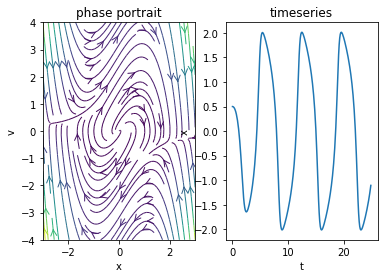

In [1]:
## Van der Pol oscillator
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.integrate import odeint

mu = 1.5 #User to choose value of mu

#### Phase Portrait ####
nx, nv = 64, 64               # grid of x, y points
x = np.linspace(-3, 3, nx); v = np.linspace(-4, 4, nv)
X, V = np.meshgrid(x, v)
xdot = V; vdot = mu*(1 - X**2)*V - X
ax1 = plt.subplot(1,2,1)      # Plot the streamlines with an appropriate colormap and arrow style
color = np.sqrt(xdot**2 + vdot**2)
ax1.streamplot(x, v, xdot, vdot, color = color, linewidth=1, density=1, arrowstyle='->', arrowsize=1.5)
plt.xlabel('x'); plt.ylabel('v'); plt.title('phase portrait')

#### Timeseries ####
def flow(f, t):
    x = f[0];     v = f[1]
    xdot = v;     vdot = mu*(1 - x**2)*v - x
    ddt = [xdot, vdot]
    return ddt 
f0 = [0.5, 0]  # Plot
t = np.arange(0,25,0.1)
f = odeint(flow, f0, t)
ax1 = plt.subplot(1,2,2)
plt.plot(t,f[:,0])
plt.xlabel('t'); plt.ylabel('x'); plt.title('timeseries')

<div>
<img src="figures/Fig5_1_4.png" width="700"/>
</div>

$ $Solution for $\mu = 1.5$, starting from $(x, \dot{x}) = (0.5, 0)$ at $t = 0$

So we can see that limit cycles are not generally a circle (signals are not sinusoidal), and must generally be found  numerically.

## 5.2 Poincaré-Bendixson Theorem 

The Poincaré-Bendixson Theorem says that the dynamical possibilities in the 2-dimensional phase plane are very limited:

*In a 2D dynamical system, if a trajectory is confined to a closed, bounded region then it is either a closed orbit or it must converge on a fixed point or limit cycle.*


<div>
<img src="figures/5_PB1.png" width="600"/>
</div>

$\bullet$ The proof of this theorem is subtle, requiring advanced ideas from topology, so we won't discuss it further here


$\bullet$ To apply this theorem we must find a *trapping* region, $R$, i.e. a region in phase space for which the vector field points inwards at every point on the surface of the region. Then all trajectories in $R$ must be confined.

<div>
<img src="figures/5_PB2.png" width="500"/>
</div>

$\bullet$ If we know the region constains no stable fixed points (note that the trajectories entering $R$ cannot be closed orbits - why?), then the region must contain a stable limit cycle.



$\bullet$ This theorem does not hold in higher-dimensional systems $n \geq 3$). Trajectories may then wander around forever in a bounded region without settling down to a fixed point or closed orbit.

$\bullet$ In some cases, the trajectories are attracted to a complex geometrical object called a strange attractor; a fractal set on which the motion is *aperiodic* and *sensitive to tiny changes in the initial conditions*. This makes the motion unpredictable in the long run i.e. CHAOS! - *but this cannot happen in 2D*

#### Example

\begin{align}
\dot{r} &= r(1-r^2) + \mu r \, \mathrm{cos} \theta \quad \mathrm{for} \, r \geq 0,\\
\dot{\theta} &= 1
\end{align}

We already know there is a stable limit cycle when $\mu = 0$. But what about other values of $\mu$? (assume $\mu>0$)


$\bullet$ Firstly, find an $r_{min}$ such that $\dot{r} > 0 \, \, \forall \, \, \theta$

$\Rightarrow$ Note that $\dot{r} \geq r( 1 − r^2) − \mu r = r ( 1 − \mu − r^2 ) .$

Thus any $r_{min} \leq \sqrt{1 − \mu}$ will work.


$\bullet$ Secondly, find an $r_{max}$ such that $\dot{r} < 0 \, \, \forall \, \, \theta$

$\Rightarrow$ Similarly, $\dot{r} \leq r( 1 − r^2) + \mu r = r ( 1 + \mu − r^2 ) .$

Thus any $r_{max} \geq \sqrt{1 + \mu}$ will work.

Since there are no stable fixed points (as $\dot{\theta} = 1$), a stable limit cycle must exist for any $\mu < 1$.

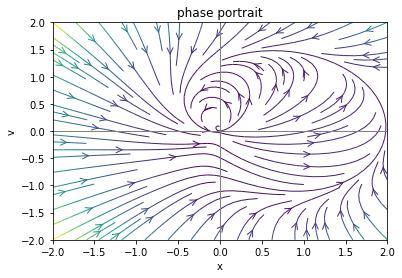

In [2]:
## Poincare Bendixson theorem
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.integrate import odeint

mu = 3 #User to choose value of mu

#### Phase Portrait ####
nx, ny = 64,64
x = np.linspace(-2, 2, nx)
y = np.linspace(-2, 2, ny)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2+Y**2)
Theta = np.arctan2(Y,X)
rdot = R*(1-R**2)+mu*R*np.cos(Theta)
thetadot = 1
xdot = rdot*np.cos(Theta)-R*np.sin(Theta)*thetadot
ydot = rdot*np.sin(Theta)+R*np.cos(Theta)*thetadot
ax1 = plt.subplot(1,1,1)      # Plot the streamlines with an appropriate colormap and arrow style
color = np.sqrt(xdot**2 + ydot**2)
ax1.streamplot(x, y, xdot, ydot, color = color, linewidth=1, density=1, arrowstyle='->', arrowsize=1.5)
plt.xlabel('x'); plt.ylabel('v'); plt.title('phase portrait'); plt.axvline(c='grey', lw=1); plt.axhline(c='grey', lw=1)

If you explored different values of $\mu$ in the script above, you would have found that our estimates were conservative. We see a closed orbit for values $\mu > 1$. Using the script, can you find a critical value of $\mu$ beyond which the closed orbits disappear?

## 5.3 Bifurcations revisited

Just as for 1D systems, we find in 2D systems that fixed points can be created, destroyed, or destabilized as parameters are varied - but now the same is true of closed orbits as well.

Hence we can begin to describe the ways in which oscillations can be turned on or off.


### 1) Saddle-node, transcritical and pitchfork bifurcations

The bifurcations of fixed points discussed above for 1D systems have analogues in *all* higher dimensions, including n = 2.

The action is confined to a 1D subspace along which the bifurcations occur, while in the extra dimensions the flow is either simple attraction to or repulsion from that subspace.



$ $e.g.$\left\{ {\begin{array}{ccc}
\dot{x} & = &  -a x + y  \\ 
\dot{y} & = & {x^2 \over 1 + x^2} - by
\end{array}} \right. \rightarrow$ genetic control system $(a,b > 0)$ 

<div>
<img src="figures/Fig5_3_1.png" width="600"/>
</div>

$ $Keep $a$ constant and vary $b \Rightarrow$ bifurcations occur along the line $y = ax$.

### 2) Hopf bifurcations

Suppose a 2-dimensional system has a *stable* fixed point. What are all the possible ways it could lose stability as a parameter $\mu$ varies?

$ $Consider the eigenvalues of the Jacobian $\lambda_1$ and $\lambda_2$

<div>
<img src="figures/fig5_3_2a.png" width="300"/>
</div>


If $\lambda_1$ or $\lambda_2$ passes through $\lambda = 0$ on varying $\mu \Rightarrow$ saddle-node, transcritical and pitchfork bifurcations.

<div>
<img src="figures/fig5_3_2b.png" width="300"/>
</div>


Alternatively $\lambda_1$ and $\lambda_2$ cross Im($\lambda$) axis onto Re($\lambda) > 0$ plane as $\mu$ is varied $\Rightarrow$ Hopf bifurcation

These figures are the only two possible scenarios for $\lambda_1$ and $\lambda_2$, since the $\lambda$s satisfy a quadratic equation with real coefficients.

#### NB The Hopf Bifurcation has no counterpart in 1-dimensional systems

### Supercritical Hopf bifurcation

A fixed point loses stability, transitioning from a stable spiral to an unstable spiral. If the latter is associated with a stable limit cycle around the original fixed point, we observe the spontaneous emergence of oscillations.

In other words, we observe a decaying oscillation before the bifurcation, and growth and saturation of a sustained oscillation after the bifurcation.

<div>
<img src="figures/fig5_3_3.png" width="800"/>
</div>

#### Simple example:

\begin{align}
\dot{r} &=   \mu r - r^3  \\ 
\dot{\theta} &= \omega + br^2
\end{align}

For $\mu<0$, origin is a stable spiral, whereas for $\mu>0$ the origin becomes unstable, but a stable limit cycle appears at $r=\sqrt{\mu}$

<div>
<img src="figures/fig5_3_4.png" width="800"/>
</div>




<div>
<img src="figures/5_SuperHopf.png" width="800"/>
</div>



### Subcritical Hopf bifurcation

A *subcritical Hopf bifurcation* is similar but with the stability properties reversed. A stable spiral and unstable limit cycle transition to an unstable spiral.

After the bifurcation, the trajectories *jump* to a *distant attractor*, which could be a fixed point, another limit cycle, infinity or - for $n \geq 3$ - a chaotic attractor (e.g. the Lorenz equations in Lecture 6).

This is much more dramatic ... and potentially dangerous in engineering!



<div>
<img src="figures/5_SubHopf.png" width="800"/>
</div>



### Conservative Systems and Degenerate Hopf bifurcations

Let's return to the example of the damped pendulum from Lecture 3:

$ \dot{\theta} = \omega , \quad \dot{\omega} = -\sin{\theta} -r\omega  $

As we change $r$ from positive to negative, the fixed point at the origin changes from a stable to an unstable spiral. 

$ r > 0$ <div>
<img src="figures/5_pendulum_damp.png" width="600"/>
</div>



But this is not a true Hopf bifurcation, because at no point do we have a *limit cycle*. At $r=0$ we have a continuous band of closed orbits.

$ r = 0$ <div>
<img src="figures/5_pendulum_cons.png" width="600"/>
</div>



This *degenerate Hopf Bifurcation* case typically occurs when a nonconservative system becomes conservative at the bifurcation point.

Fixed points in conservative systems cannot be attracting but must instead be *centres* (or saddle points).

$\bullet$ For conservative systems we can find some *conserved quantity* that is constant along trajectories. 

$\bullet$ Different trajectories have different values of that conserved quantity.

$\bullet$ They cannot meet at an attracting fixed point, as the value of the conserved quantity at that point would be undefined.

 <div>
<img src="figures/5_pendulum_damp.png" width="600"/>
</div>

## Real World Examples of Hopf Bifurcations


#### Oscillating chemical reactions

The Belousov-Zhabotinsky reaction is a famous example of the occurrence of Hopf bifurcations.

This is a complex set of more than 20 reactions amongst reagents which include malonic acid, bromate ions, sulphuric acid and a cerium catalyst. The system undergoes periodic oscillations which appear as changes in colour of the solution.

Video source: https://www.youtube.com/watch?v=IBa4kgXI4Cg
    



<div>
<img src="figures/fig5_bz5.png" width="400"/>
</div>

#### Example

$ $Lengyel et al. (1990) derived a simple model for another oscillating chemical reaction between $ClO_2$, iodine ($I_2$) and malonic acid ($MA$)

$$\begin{eqnarray*}
MA + I_2 & \rightarrow & IMA + I^- + H^+ \\
ClO_2 + I^- & \rightarrow & ClO_2^- + {1 \over 2} I_2\\
ClO_2 + 4 I^- + 4 H^+ & \rightarrow & Cl^- + 2I_2 + 2H_2O
\end{eqnarray*}$$


After suitable nondimensionalisation (see Strogatz Ch. 8 for details), this reduces to the dynamical system

$$ \begin{eqnarray*}
\dot{x} & = & a - x - {4 xy \over 1 + x^2}\\
\dot{y} & = & bx \left( 1 - {y \over 1 + x^2} \right) 
\end{eqnarray*} $$

$ $where $a$ and $b$ are constants.

Text(0.5, 1.0, 'timeseries')

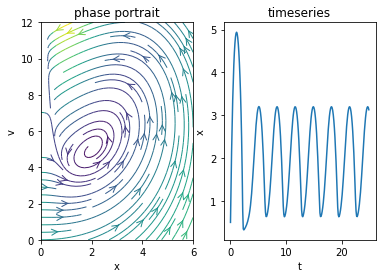

In [3]:
## Lengyel chemical reactions
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.integrate import odeint

#User to choose value of a, b
a = 10
b = 2 

#### Phase Portrait ####
nx, ny = 64, 64               # grid of x, y points
x = np.linspace(0, 6, nx); y = np.linspace(0, 12, ny)
X, Y = np.meshgrid(x, y)
xdot = a - X - (4*X*Y)/(1+X**2)
ydot = b*X*( 1 - (Y/(1+X**2)))
ax1 = plt.subplot(1,2,1)      # Plot the streamlines with an appropriate colormap and arrow style
color = np.sqrt(xdot**2 + ydot**2)
ax1.streamplot(x, y, xdot, ydot, color = color, linewidth=1, density=1, arrowstyle='->', arrowsize=1.5)
plt.xlabel('x'); plt.ylabel('v'); plt.title('phase portrait')

#### Timeseries ####
def flow(f, t):
    x = f[0];     y = f[1]
    xdot = a - x - (4*x*y)/(1+x**2)
    ydot = b*x*( 1 - (y/(1+x**2)))
    ddt = [xdot, ydot]
    return ddt 
f0 = [0.5, 0]  # Plot
t = np.arange(0,25,0.1)
f = odeint(flow, f0, t)
ax1 = plt.subplot(1,2,2)
plt.plot(t,f[:,0])
plt.xlabel('t'); plt.ylabel('x'); plt.title('timeseries')

This nonlinear, 2D system can exhibit periodic oscillations ... see Problem Set 1, Q7 for more details.


<div>
<img src="figures/5_Lengyel.png" width="800"/>
</div>


Closely related are waves of excitation in neural or cardiac tissue.

#### Coiling Honey 

Video Source: https://www.youtube.com/watch?v=zz5lGkDdk78


####  Von Karman Vortex Street

video source: https://www.youtube.com/watch?v=3mULL6O6f38



<div>
<img src="figures/5_VKVS_clouds.jpg" width="800"/>
</div>



#### Aerofoil flutter

Video source: https://www.youtube.com/watch?v=qpJBvQXQC2M

#### Galloping Gertie

$\bullet$ Bridge over the Tacoma Narrows in Washington State, built 1940

$\bullet$ Example of aerodynamic flutter - resonance between aerodynamic forcings and natural vibration modes

$\bullet$ For any constant wind speed above about 35 mph, the amplitude of the flutter oscillation increases - it is is self sustaining

Video source: https://www.youtube.com/watch?v=hyiYjthZimM


#### El Nino Southern Oscillation

https://www.youtube.com/watch?v=NFng9943Ruc


<div>
<img src="figures/5_ENSO_DO_Hopf.jpg" width="800"/>
</div>